In [2]:
import numpy as np

print("="*50)
print("Exercise 4")
print("="*50)

# Task 1: 5x5 border matrix
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

print("5x5 Border Matrix:")
print(matrix)

# Task 2: Normalize random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized_data = (
    random_data - random_data.mean(axis=0)
) / random_data.std(axis=0)

print("\nMeans after normalization:")
print(normalized_data.mean(axis=0))

print("\nStandard deviations after normalization:")
print(normalized_data.std(axis=0))

# Task 3: Linear Regression using Normal Equation

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTrue Coefficients:")
print(true_theta)

print("\nEstimated Coefficients:")
print(theta_hat)

Exercise 4
5x5 Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Means after normalization:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Standard deviations after normalization:
[1. 1. 1.]

True Coefficients:
[ 2.5 -1.2  3.7]

Estimated Coefficients:
[ 2.51723721 -1.19783796  3.72399266]


In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(
        ['CS', 'Math', 'Physics', 'Biology'],
        n_students
    ),
    'year': np.random.choice([1,2,3,4], n_students),
    'exam_score': np.random.normal(75,10,n_students).clip(0,100),
    'assignments_completed': np.random.randint(0,11,n_students),
    'hours_studied': np.random.normal(15,5,n_students).clip(1,40)
}

df = pd.DataFrame(data)

# Introduce missing values
df.loc[np.random.choice(n_students,10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students,5), 'hours_studied'] = np.nan

print("="*50)
print("Dataset Information")
print("="*50)

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Fill exam_score with major mean
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill hours_studied with year median
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

# Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()

print("\nAverage Score by Major")
print(avg_scores)

best_major = avg_scores.idxmax()

print(f"\nBest Performing Major: {best_major}")

# Correlation
correlation = df['hours_studied'].corr(df['exam_score'])

print(f"\nCorrelation: {correlation:.3f}")

# Performance Categories

conditions = [
    df['exam_score'] > 90,
    (df['exam_score'] >= 80) & (df['exam_score'] <= 90),
    (df['exam_score'] >= 70) & (df['exam_score'] < 80),
    df['exam_score'] < 70
]

categories = [
    'Excellent',
    'Good',
    'Average',
    'Needs Improvement'
]

df['performance'] = np.select(
    conditions,
    categories,
    default='Average'
)

# Major-Year Summary

summary = df.groupby(
    ['major', 'year']
).agg(
    student_count=('student_id', 'count'),
    avg_score=('exam_score', 'mean'),
    avg_hours=('hours_studied', 'mean')
)

print("\nMajor-Year Summary")
print(summary)

# Top Students

top_students = df.nlargest(
    int(len(df)*0.05),
    'exam_score'
)

print("\nTop Students")
print(top_students[['student_id','exam_score']])

# Pivot Table

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table")
print(pivot)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

Missing Values
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Average Score by Major
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Best Performing Major: CS

Correlation: -0.056



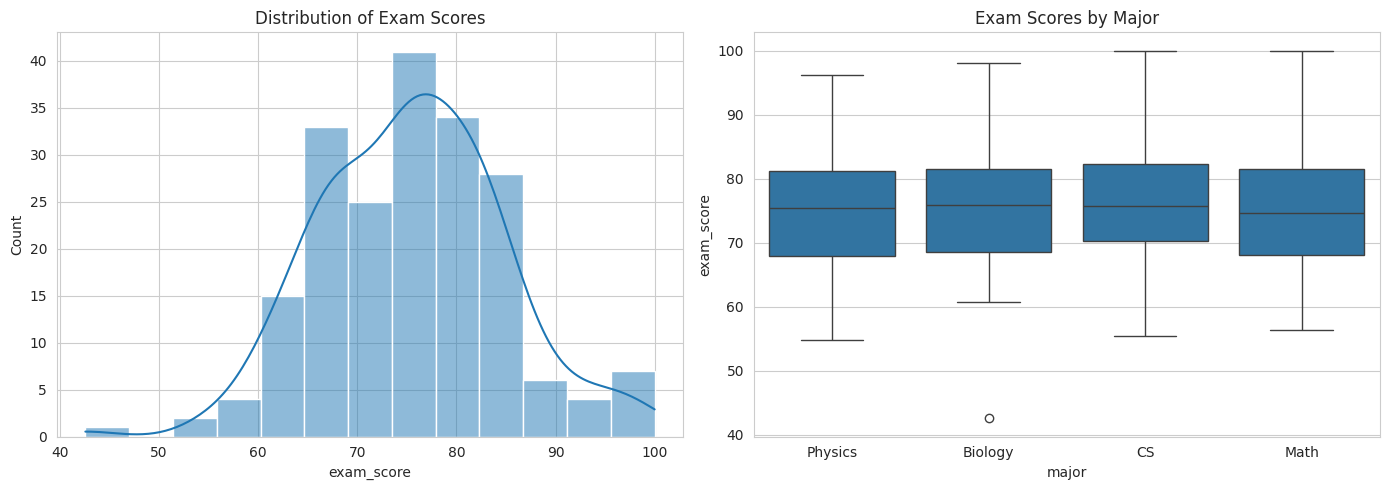

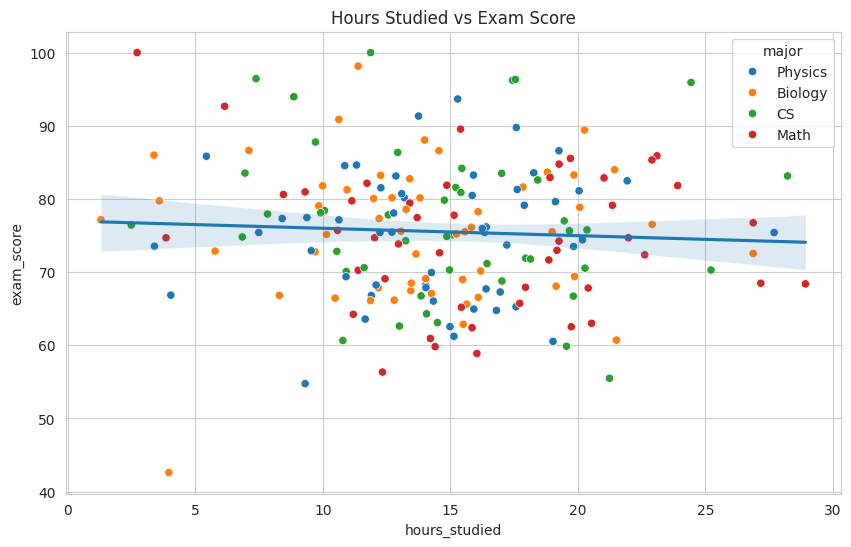

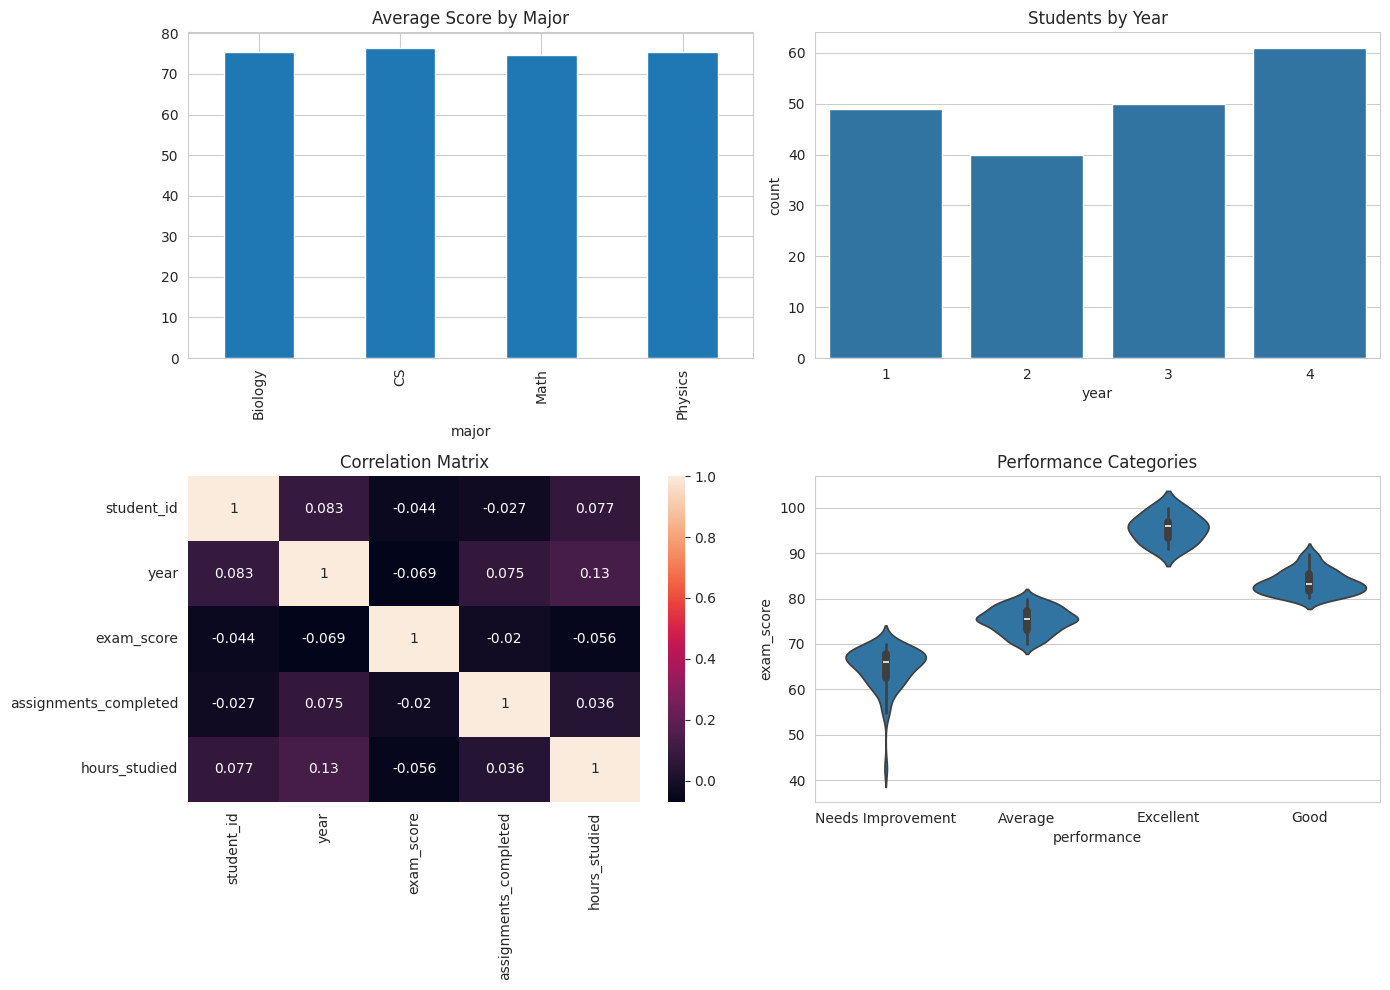

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ----------------------------
# Task 1
# ----------------------------

fig, axes = plt.subplots(1,2,figsize=(14,5))

sns.histplot(
    df['exam_score'],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Exam Scores")

sns.boxplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[1]
)

axes[1].set_title("Exam Scores by Major")

plt.tight_layout()
plt.show()

# ----------------------------
# Task 2
# ----------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)

plt.title("Hours Studied vs Exam Score")
plt.show()

# ----------------------------
# Task 3 Dashboard
# ----------------------------

fig, axes = plt.subplots(2,2,figsize=(14,10))

# Average score by major
avg_scores.plot(
    kind='bar',
    ax=axes[0,0]
)
axes[0,0].set_title("Average Score by Major")

# Student count by year
sns.countplot(
    data=df,
    x='year',
    ax=axes[0,1]
)
axes[0,1].set_title("Students by Year")

# Correlation Heatmap
numerical_cols = df.select_dtypes(include=np.number)

sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Correlation Matrix")

# Violin Plot
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1,1]
)

axes[1,1].set_title("Performance Categories")

plt.tight_layout()
plt.show()

           customer_count    avg_income     avg_clv      total_clv
age_group                                                         
18-25                  69  51805.879852  704.492597   48609.989225
26-35                  73  48747.148046  747.738562   54584.915035
36-50                 160  48516.895668  732.796612  117247.457917
51-70                 186  50713.163384  762.693498  141860.990683

Top 10% Customers
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663     36-50  
24  

/tmp/ipykernel_12126/2231435489.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_analysis = customers.groupby(


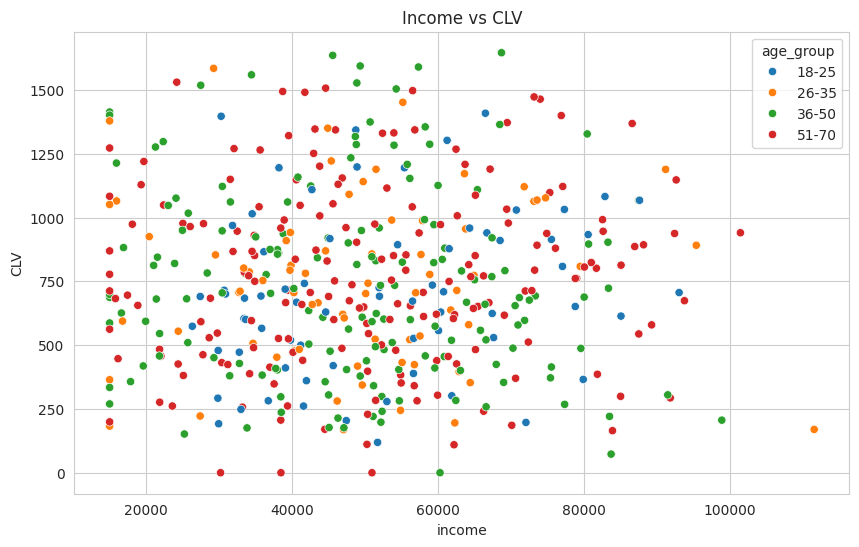

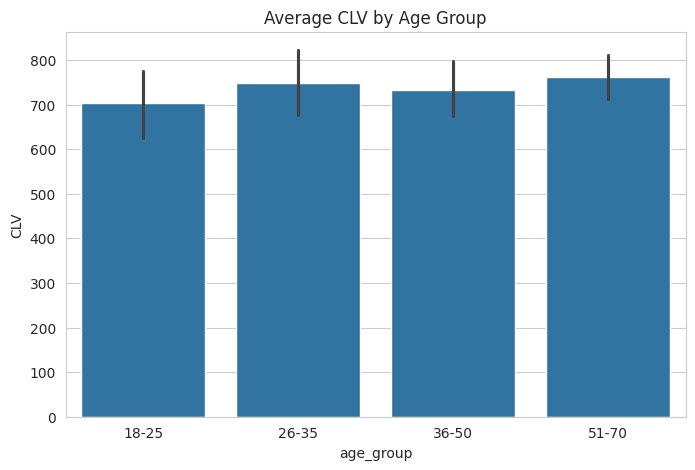

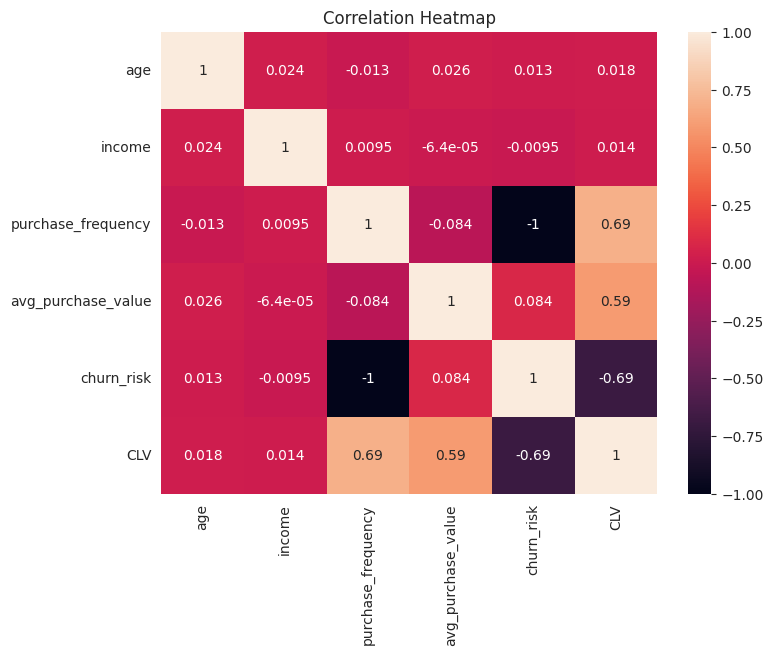

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n_customers = 500

ages = np.random.randint(18,70,n_customers)
income = np.random.normal(
    50000,
    20000,
    n_customers
).clip(15000,150000)

purchase_freq = np.random.poisson(
    5,
    n_customers
)

avg_purchase_value = np.random.normal(
    100,
    30,
    n_customers
).clip(10,500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# CLV

max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = (
    1 - customers['purchase_frequency']/max_freq
)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

# Age Groups

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18,25,35,50,70],
    labels=[
        '18-25',
        '26-35',
        '36-50',
        '51-70'
    ]
)

# Group Analysis

group_analysis = customers.groupby(
    'age_group'
).agg(
    customer_count=('age','count'),
    avg_income=('income','mean'),
    avg_clv=('CLV','mean'),
    total_clv=('CLV','sum')
)

print(group_analysis)

# Top 10%

threshold = customers['CLV'].quantile(0.90)

top_customers = customers[
    customers['CLV'] >= threshold
]

print("\nTop 10% Customers")
print(top_customers.head())

# ------------------------
# Visualization 1
# ------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title("Income vs CLV")
plt.show()

# ------------------------
# Visualization 2
# ------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=customers,
    x='age_group',
    y='CLV'
)

plt.title("Average CLV by Age Group")
plt.show()

# ------------------------
# Visualization 3
# ------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    customers.select_dtypes(
        include=np.number
    ).corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()